# Phase-Based Connectivity Analysis

In [2]:
import matplotlib.pyplot as plt
import mne
import mne_connectivity
import numpy as np


## Utility Functions

In [3]:
connectivity_methods={"plv": "Phase Locking Value (PLV)",
                      "pli": "Phase Lag Index (PLI)"}

def _plot_connectivity_matrix(info, connectivity, freq):
    method = connectivity_methods[connectivity.method]
    data = connectivity.get_data(output="dense")
    freqs = np.asarray(connectivity.freqs)
    freq_idx = np.argmin(np.abs(freq-freqs))
    ch_names = info["ch_names"]
    im = plt.imshow(data[:, :, freq_idx])
    plt.colorbar(im, label=f"{method} [a.u.]")
    plt.xticks(range(0, len(ch_names), 2), ch_names[::2], rotation=45, fontsize=8)
    plt.yticks(range(0, len(ch_names), 2), ch_names[::2], rotation=45, fontsize=8)
    plt.xlabel("Seed channels")
    plt.ylabel("Target channels")
    plt.title(f"{method} at {freq} Hz")

def _plot_connectivity_topo(ch, info, connectivity, freq):
    method = connectivity_methods[connectivity.method]
    freqs = np.asarray(connectivity.freqs)
    freq_idx = np.argmin(np.abs(freq-freqs))
    ch_idx = info["ch_names"].index(ch)
    data = connectivity.get_data(output="dense")
    topo = data[ch_idx, :, freq_idx] + data[:, ch_idx, freq_idx]
    mask = np.zeros(len(info["ch_names"]), dtype=bool)
    mask[ch_idx] = True
    fig, ax = plt.subplots(1,1)
    im, _ = mne.viz.plot_topomap(
        topo, pos=info, axes=ax, mask=mask, names=info["ch_names"], cmap="viridis", show=False, vlim=(topo.min(), topo.max()),
        mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='r', markersize=15))
    plt.colorbar(im, ax=ax, label=f"{method} [a.u.]")
    fig.suptitle(f"{method} for {ch} at {freq} Hz")
    plt.show()

def _plot_connectivity_per_freq(ch1, ch2, info, connectivity):
    data = connectivity.get_data(output="dense")
    method = connectivity_methods[connectivity.method]
    target_idx = info["ch_names"].index(ch1)
    seed_idx = info["ch_names"].index(ch2)
    if target_idx < seed_idx:
        target_idx, seed_idx = seed_idx, target_idx
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    topo = np.zeros(data.shape[0])
    mask = np.zeros(len(info["ch_names"]), dtype=bool)
    ch1_idx = info["ch_names"].index(ch1)
    ch2_idx = info["ch_names"].index(ch2)
    mask[ch1_idx] = True
    mask[ch2_idx] = True
    mne.viz.plot_topomap(
        topo, pos=info, axes=ax[0], mask=mask, names=info["ch_names"], show=False,
        mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='r', markersize=15))
    ax[1].plot(connectivity.freqs, data[target_idx, seed_idx, :])
    ax[1].set(xlabel="Frequency [Hz]", ylabel=f"{method} [a.u.]", ylim=(0,1))
    fig.suptitle(f"{method} between {ch1} and {ch2}")
    plt.show()

def _simulate_sync_signals(n_epochs=40, dur=4, fs=500, freq=10, phase_lag=0,
                           noise_level=0.5, random_phase=False):
    n = int(dur * fs)
    t = np.linspace(0, dur, n)
    rng = np.random.RandomState(42)

    sig1 = np.zeros((n_epochs, n))
    sig2 = np.zeros((n_epochs, n))

    for i in range(n_epochs):
        phi = rng.uniform(0, 2 * np.pi) if random_phase else 0
        sig1[i] = np.sin(2 * np.pi * freq * t + phi) + rng.randn(n) * noise_level
        sig2[i] = np.sin(2 * np.pi * freq * t + phi + phase_lag) + rng.randn(n) * noise_level

    return t, sig1, sig2

def _compute_phase(sig, fs, freq):
    n = sig.shape[1]
    freqs = np.fft.rfftfreq(n, 1 / fs)
    freq_idx = np.argmin(np.abs(freqs - freq))
    phase = np.angle(np.fft.rfft(sig, axis=1)[:, freq_idx])
    return phase

def _plot_phase_distribution(phase):
    bins = np.linspace(-np.pi, np.pi, 25)
    fig, ax = plt.subplots(subplot_kw=dict(projection="polar"))
    counts, edges = np.histogram(phase, bins=bins)
    ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge")

class utils:
    simulate_sync_signals = _simulate_sync_signals
    plot_connectivity_matrix = _plot_connectivity_matrix
    plot_connectivity_per_freq = _plot_connectivity_per_freq
    plot_connectivity_topo = _plot_connectivity_topo
    plot_phase_distribution = _plot_phase_distribution
    compute_phase = _compute_phase

The brain can be understood as a network of interconnected nodes (neurons, areas etc.). When two nodes work together, we expect their patterns of activity to be synchronized in time. Functional connectivity analysis methods measure this synchrony to draw conclusions about the interactions between nodes.

However, there is a fundamental problem when analyzing functional connectivity from EEG sensor data. Because the brain is a conductive medium, synchronized activity between two sites may reflect passive **volume conductance** rather than actual neural interactions. To overcome this limitation, we can preprocess the data to remove the effect of volume conductance or only focus on synchrony with a non-zero time lag (since electrical conductance is instantaneous).

In this notebook you are going to learn to:
- Interpret plots of phase and phase-difference distributions
- Use the `mne_connectivity` package
- Compute two different phase-based connectivity measures **phase-locking value (PLV)** and **phase-lag index (PLI)**
- Apply the current source density transform to remove the effect of volume conductance


## Extracting and Visualizing Phase Information

### Background

The phase of a sinusoid represents how much it is **shifted** relative to the origin and ranges from $-\pi$ to $+\pi$. The **Fourier transform**, which decomposes a signal into a set of sine waves, gives us a phase value at every frequency. Repeating this across multiple epochs gives us the **phase distribution** for the recorded neural signal. In this section, we are going to simulate some simple synchronized oscillations and visualize their phase distributions to build some intuition about interpreting phase information.

### Exercises

In the following exercises, you are going to compute the phase distribution across multiple epochs of a simulated signal and visualize them in polar plots. Rather than implementing these operations yourself, you can use two simple utility functions, allowing you to focus on the interpretation of the results. Here's how you use the utility functions:

| Code | Description |
| --- | --- |
| `utils.simulate_sync_signals(dur, fs, freq, phase_lag)` | Simulate two signals with a sinusoidal oscillation at `freq` Hz and a fixed `phase_lag` |
| `utils.compute_phase(sig, fs, freq)` | Compute the phase of `sig` at `freq` Hz using the DFT |
| `utils.plot_phase_distribution(phase)` | Plot the distribution of `phase` values in a polar histogram |

The code below generates two signals with a 2 Hz oscillation at a fixed phase lag.

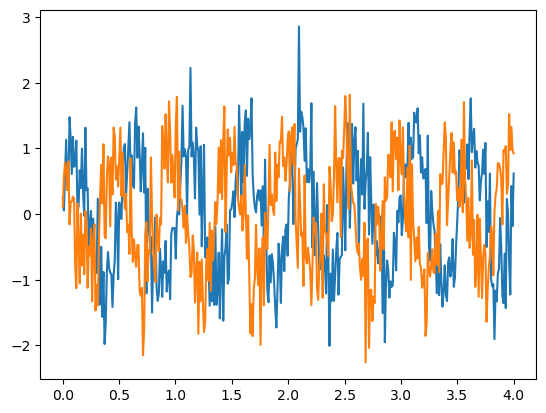

In [4]:
t, sig1, sig2 = utils.simulate_sync_signals(
    dur=4, fs=100, freq=2, phase_lag=2
)
plt.plot(t, sig1[0])
plt.plot(t, sig2[0])

**Example**: Compute the phase of `sig1` at 10 Hz and plot the phase distribution in a polar plot.

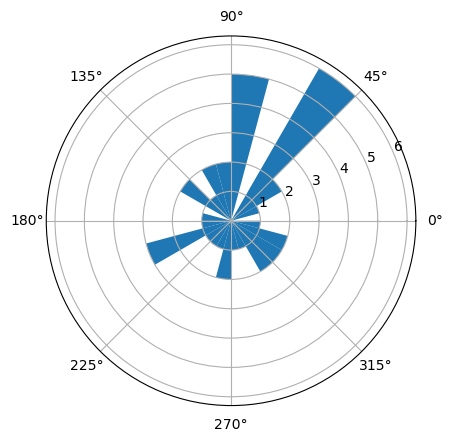

In [5]:
phase = utils.compute_phase(sig1, fs=100, freq=10)
utils.plot_phase_distribution(phase)

**Exercise**: Compute the phase of `sig1` at 2 Hz and plot the phase distribution in a polar plot. What is the phase of the signal?

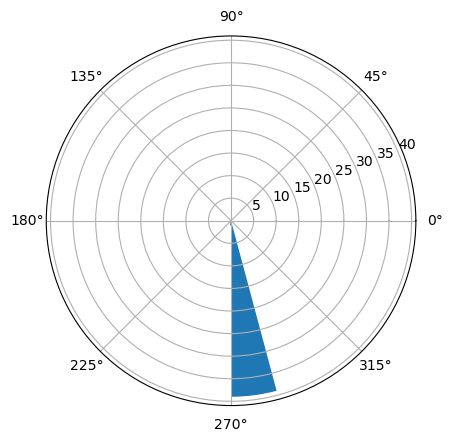

In [6]:
phase = utils.compute_phase(sig1, fs=100, freq=2)
utils.plot_phase_distribution(phase)

**Exercise**: Compute the phase of `sig2` at 2 Hz and plot the phase distribution in a polar plot. What is the phase of the signal?

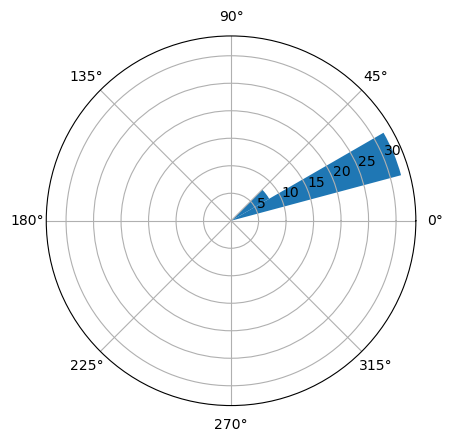

In [7]:
phase = utils.compute_phase(sig2, fs=100, freq=2)
utils.plot_phase_distribution(phase)

Real neural signals do not have a constant phase. Run the cell below to repeat the simulation with a random phase offset for every epoch (while keeping the phase lag between the signals constant).

In [8]:
t, sig1, sig2 = utils.simulate_sync_signals(
    dur=4, fs=100, freq=2, phase_lag=2, random_phase=True
)

**Exercise**: Compute and plot the phase distribution for `sig1` and `sig2` separately at 2 Hz. Do the individual signals still show a dominant phase?

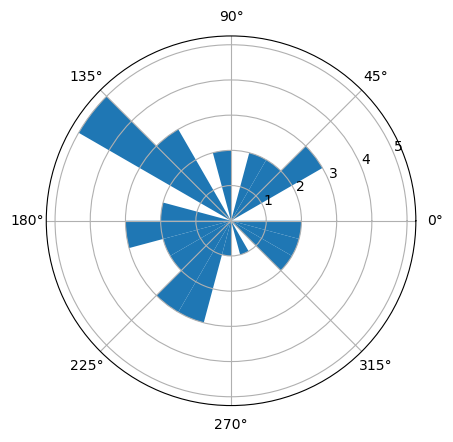

In [9]:
phase = utils.compute_phase(sig1, fs=100, freq=2)
utils.plot_phase_distribution(phase)

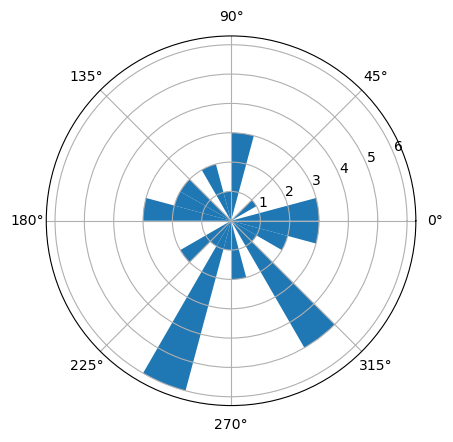

In [10]:
phase = utils.compute_phase(sig2, fs=100, freq=2)
utils.plot_phase_distribution(phase)

**Example**: Compute the phase difference between `sig1` and `sig2` at 10 Hz and visualize it in a polar plot.

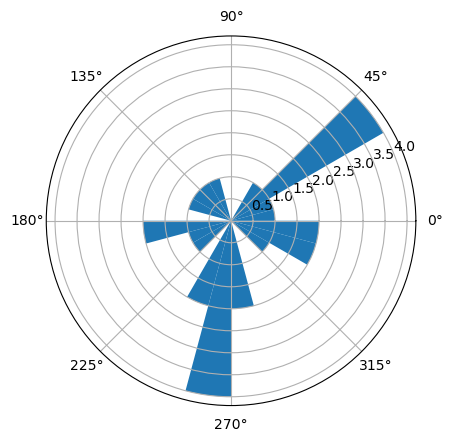

In [11]:
phase1 = utils.compute_phase(sig1, fs=100, freq=10)
phase2 = utils.compute_phase(sig2, fs=100, freq=10)
phase_diff = phase1 - phase2
utils.plot_phase_distribution(phase_diff)


**Exercise**: Compute the phase difference between `sig1` and `sig2` at 2 Hz and visualize it in a polar plot. What is the phase lag between the signals?

Looking at the consistency of the phase difference across epochs is how phase-based connectivity measures work.

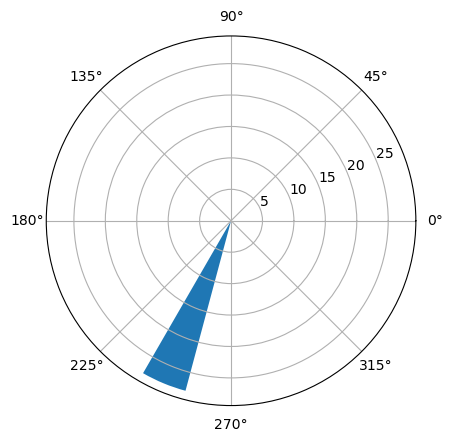

In [12]:
phase1 = utils.compute_phase(sig1, fs=100, freq=2)
phase2 = utils.compute_phase(sig2, fs=100, freq=2)
phase_diff = phase1 - phase2
utils.plot_phase_distribution(phase_diff)

## Simulating Data using a Forward Model

The simulated data from the previous section was useful for building some intuition about phase and phase difference distributions, but it's too simplistic to test how phase-based connectivity measures would perform on real neural data. The cell below runs a script that simulates realistic EEG data from a source model with two synchronous oscillations in primary auditory cortex and Broca's area - a connectivity pattern that would be expected during speech comprehension.

In this section, you are not expected to write any code yourself. Just run the simulation, visualize the results and think about for which pairs of electrodes you would expect to find high connectivity values.

In [13]:
# this may take a while
%run simulation.py

Loading data and building forward model...
Simulating source activity...
Projecting sources to EEG and adding noise...


C:\Users\olebi\Projects\EEG-Course\08_connectivity_analysis\simulation.py:74: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  mne.simulation.add_noise(


Epoching...
Saving...
Done.


Load the simulated data.

In [14]:
epochs = mne.read_epochs("sim-epo.fif")
stc = mne.read_source_estimate("sim")

Reading c:\Users\olebi\Projects\EEG-Course\08_connectivity_analysis\sim-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
99 matching events found
No baseline correction applied
0 projection items activated


Plot the source locations on the cortical surface.

In [15]:
fs_dir = mne.datasets.fetch_fsaverage(verbose=False)
brain = mne.viz.Brain("fsaverage", hemi="both", subjects_dir=fs_dir.parent, surf="inflated")
colors = ["blue", "red"]
vertices = [(v, "lh") for v in stc.vertices[0]] + [(v, "rh") for v in stc.vertices[1]]
for (vertex, hemi), color in zip(vertices, colors):
    brain.add_foci(vertex, coords_as_verts=True, hemi=hemi, color=color)

Using pyvistaqt 3d backend.


Plot the time course of the source signals.

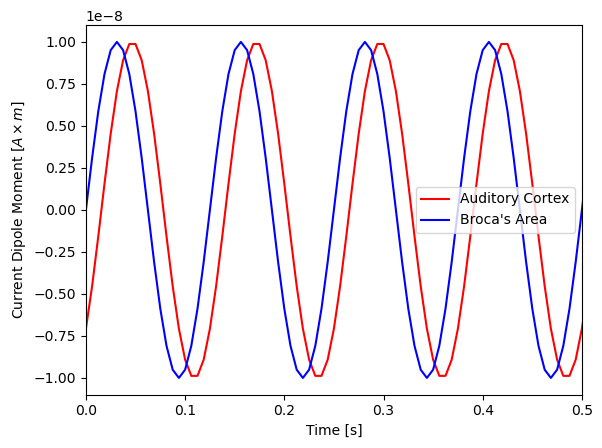

In [16]:
plt.plot(stc.times, stc.data[0], color="red", label="Auditory Cortex");
plt.plot(stc.times, stc.data[1], color="blue", label="Broca's Area");
plt.xlim(0, 0.5)
plt.xlabel("Time [s]")
plt.ylabel("Current Dipole Moment [$A \\times m$]")
plt.legend()

Plot the ERP for the simulated EEG data.

No projector specified for this dataset. Please consider the method self.add_proj.


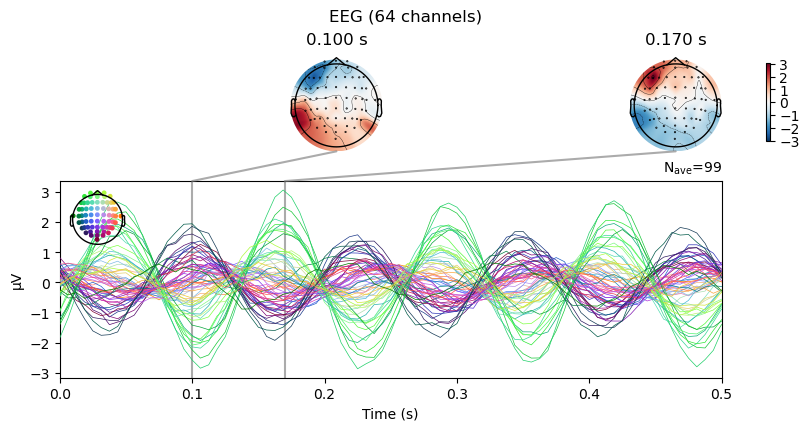

In [17]:
epochs.average().crop(0, 0.5).plot_joint(times=[0.1, 0.17]);

## Phase Locking Value (PLV)

### Background

PLV measures the consistency of the phase difference between two signals across trials.

$$\text{PLV} = \left| \frac{1}{N} \sum_{n=1}^{N} e^{i \Delta\phi_n} \right|$$

Where $\Delta\phi_n$ is the phase difference at trial $n$. The PLV ranges from **0 to 1** where a PLV of 1 indicates a perfectly consistent phase-locked relationship and 0 indicates a uniform distribution of phase differences.

In EEG, a high PLV may reflect genuine neural connectivity but it could also be due to volume conductance because activity from one source can spread to multiple channels.

### Exercises

We'll start this section by computing the PLV on random phase differences drawn from a distribution to get an intuition of what high and low PLVs mean. Then, we'll use the `mne_connectivity` package to analyze and visualize the patterns of connectivity in the simulated data. We can visualize the connectivity in two ways:
1. We can select a frequency and channel and visualize the connectivity of that channel with every other one as a topographical map.
2. We can pick a pair of channels and visualize their connectivity across all frequencies.

Here are the code examples for solving the exercises:

| Code | Description |
| --- | --- |
| `con = mne_connectivity.spectral_connectivity_epochs(epochs, method="plv")` | Compute the PLV connectivity for all `epochs` |
| `con.get_data(output="dense")` | Get the 3D connectivity matrix with shape `(n_channels, n_channels, n_frequencies)`|
| `utils.plot_connectivity_matrix(info, connectivity, freq)` | Plot the `connectivity` at frequency `freq` for the channels in `info` |
| `utils.plot_connectivity_topo(ch, info, connectivity, freq)` | Create a topoplot for the connectivity between `ch` and every other channel at the frequency `freq` |
| `utils.plot_connectivity_per_freq(ch1, ch2, info, connectivity)` | Plot the connectivity between `ch1` and `ch2` across all frequencies |

**Example**: The cell below simulates the phase differences across trials using the von Mises distribution (the circular analog of the normal distribution). Calculate the PLV using the formula `np.abs(np.mean(np.exp(1j * phase_diff)))`.

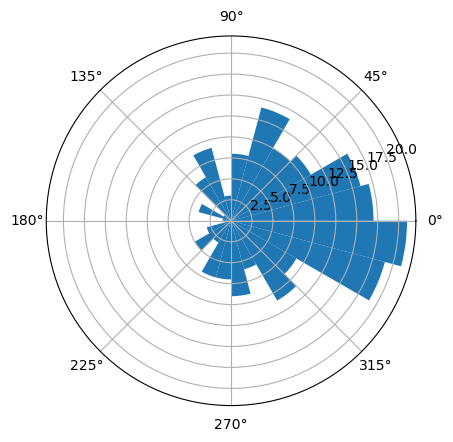

In [18]:
rng = np.random.default_rng(42)
phase_diff = rng.vonmises(mu=0, kappa=1, size=200)
utils.plot_phase_distribution(phase_diff)

In [19]:
plv = np.abs(np.mean(np.exp(1j * phase_diff)))
plv

np.float64(0.42013398734196444)

**Exercise**: The cell below creates and plots another distribution of phase differences. Do you think the PLV would be higher or lower compared to the previous example? Compute the PLV using the formula `np.abs(np.mean(np.exp(1j * phase_diff)))` to confirm.

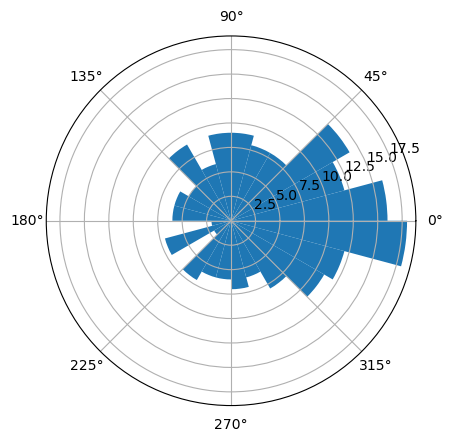

In [20]:
rng = np.random.default_rng(42)
phase_diff = rng.vonmises(mu=0, kappa=0.5, size=200)
utils.plot_phase_distribution(phase_diff)

In [21]:
plv = np.abs(np.mean(np.exp(1j * phase_diff)))
plv

np.float64(0.2583880292730586)

**Exercise**: The cell below creates and plots another distribution of phase differences. How do you think the PLV would compare to the previous examples? Compute the PLV to confirm.

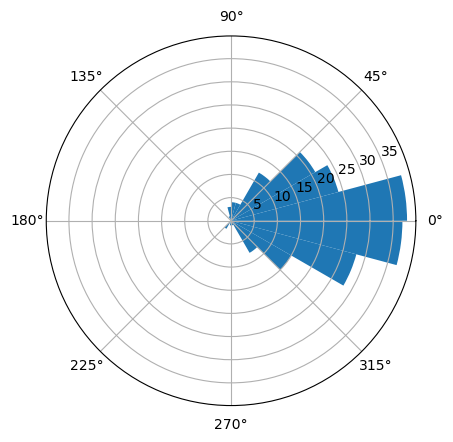

In [22]:
rng = np.random.default_rng(42)
phase_diff = rng.vonmises(mu=0, kappa=3, size=200)
utils.plot_phase_distribution(phase_diff)

In [23]:
plv = np.abs(np.mean(np.exp(1j * phase_diff)))
plv

np.float64(0.8250162719899764)

**Example**: Estimate the pairwise connectivity for all electrode pairs on the simulated `epochs` using the phase locking value `"plv"` method for frequencies up to `fmax=80` Hz. Then, get the connectivity matrix and print its shape - the dimensions are `(n_channels, n_channels, n_frequencies)`.

In [24]:
con_plv = mne_connectivity.spectral_connectivity_epochs(epochs, method="plv", fmax=80, verbose=False)
data = con_plv.get_data(output="dense")
data.shape


(64, 64, 236)

**Exercise**: Estimate the pairwise connectivity for all electrode pairs using the phase locking value `"plv"` method for frequencies up to `fmax=40` Hz. Then, get the connectivity matrix and print its shape. How does it differ from the previous example?

In [25]:
con_plv = mne_connectivity.spectral_connectivity_epochs(epochs, method="plv", fmax=40, verbose=False)
data = con_plv.get_data(output="dense")
data.shape


(64, 64, 116)

**Example**: Plot the matrix of estimated connectivity values at `20` Hz.

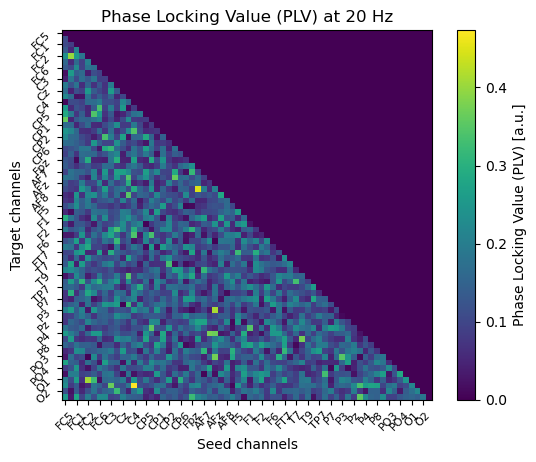

In [26]:
freq = 20
utils.plot_connectivity_matrix(info=epochs.info, connectivity=con_plv, freq=freq)

**Exercise**: Plot the matrix of estimated connectivity values at `8` Hz.

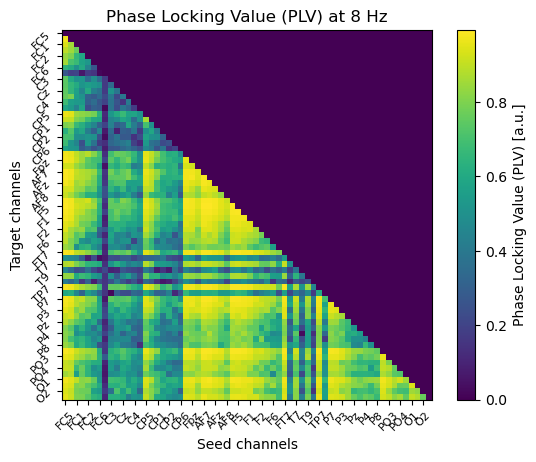

In [28]:
freq = 8
utils.plot_connectivity_matrix(info=epochs.info, connectivity=con_plv, freq=freq)

**Example**: Plot the connectivity between `"F7"` (close to the simulated source in Broca's area) and all other electrodes at `8` Hz as a topoplot.

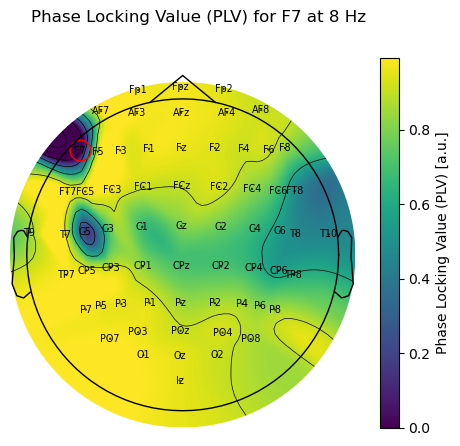

In [29]:
freq = 8
ch = "F7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_plv, freq=freq)


**Exercise**: Plot the connectivity between `"T7"` (close to the source in the primary auditory cortex) and all other electrodes at `8` Hz as a topoplot.

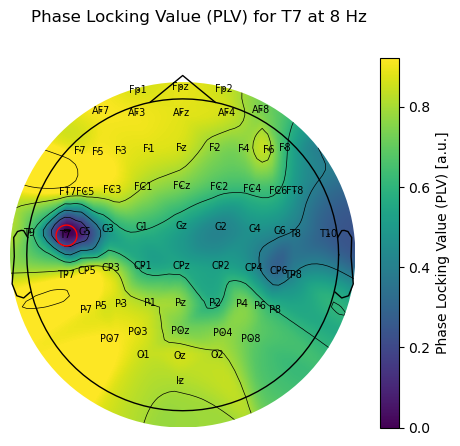

In [30]:
freq = 8
ch = "T7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_plv, freq=freq)

**Example**: Plot the connectivity between `"T7"` (primary auditory cortex) and `"F7"` (Broca's area) across all frequencies.

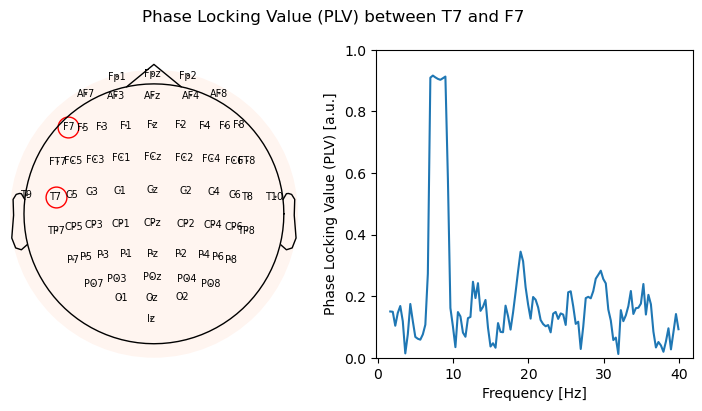

In [32]:
ch1 = "T7"
ch2 = "F7"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=con_plv)

**Exercise**: Plot the connectivity between `"T7"` (primary auditory cortex) and its neighbor `"T9"` across frequencies. Does the high phase locking value here reflect connectivity between actual neural sources?

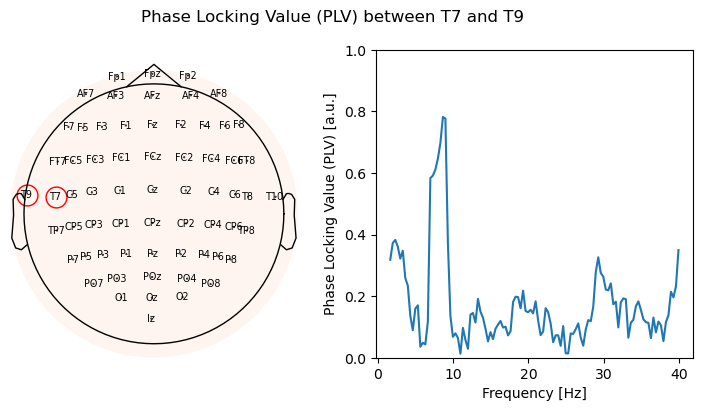

In [33]:
ch1 = "T7"
ch2 = "T9"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=con_plv)

## Phase Lag Index (PLI)

### Background

Instead of averaging the phase differences, PLI only looks at which side the phase differences fall on. It asks: does one signal consistently lead the other? The formula is

$$\text{PLI} = \left| \frac{1}{N} \sum_{n=1}^{N} \text{sgn}(\Delta\phi_n) \right|$$

where $\text{sgn}(\Delta\phi_n)$ is $+1$ if the first signal leads the second and $-1$ if it lags. A PLI of 1 indicates that one signal consistently leads while a PLI of 0 means that the phase differences are symmetric around 0.

Because the phase difference for volume-conducted signals is 0, PLI suppresses these interactions which inflate the PLV. The trade-off is that PLI is less sensitive than PLV — a weak but consistent non-zero lag may be harder to detect, and small perturbations around zero can flip the sign.

### Exercises

The exercises follow the same pattern as in the previous section. We'll first compute the PLI for random phase differences drawn from a distribution and then apply PLI to our simulated data. Throughout the section, we'll compare PLI to PLV to get an intuition on how these measures differ.

| Code | Description |
| --- | --- |
| `mne_connectivity.spectral_connectivity_epochs(epochs, method="pli")` | Compute the spectral connectivity for all `epochs` using the phase lag index (`"pli"`) method |
| `utils.plot_connectivity_topo(ch, info, connectivity, freq)` | Create a topoplot for the connectivity between `ch` and every other channel at the frequency `freq` |

**Example**: The cell below draws and visualizes random phase differences from the von Mises distribution and computes the PLV. Compute the PLI using the formula `pli = np.abs(np.mean(np.sign(phase_diff)))` and compare it to the PLV.

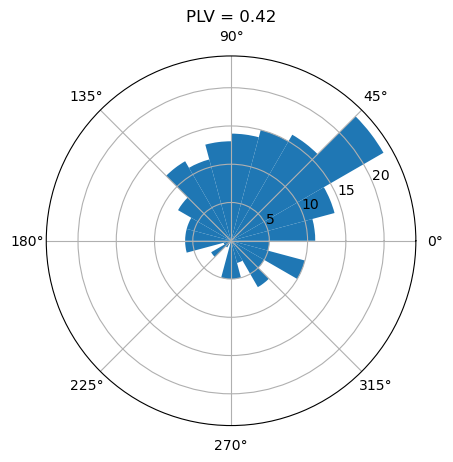

In [34]:
rng = np.random.default_rng(42)
phase_diff = rng.vonmises(mu=1, kappa=1, size=200)
utils.plot_phase_distribution(phase_diff)
plv = np.abs(np.mean(np.exp(1j * phase_diff)))
plt.title(f"PLV = {plv.round(3)}");

In [35]:
pli = np.abs(np.mean(np.sign(phase_diff)))
pli

np.float64(0.49)

**Exercise**: The cell below generates another set of phase differences with the same PLV as in the previous example. How do you think the PLI will compare to the previous example? Compute it using the formula `pli = np.abs(np.mean(np.sign(phase_diff)))` to confirm.

Text(0.5, 1.0, 'PLV = 0.42')

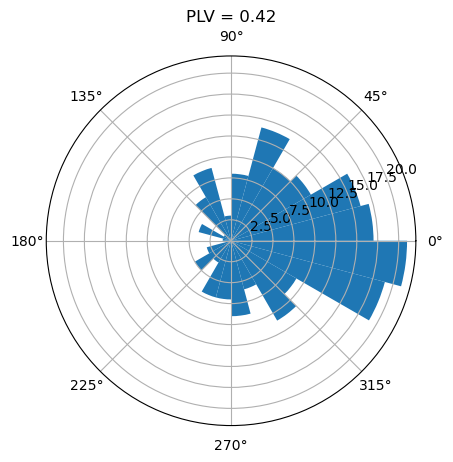

In [36]:
rng = np.random.default_rng(42)
phase_diff = rng.vonmises(mu=0, kappa=1, size=200)
utils.plot_phase_distribution(phase_diff)
plv = np.abs(np.mean(np.exp(1j * phase_diff)))
plt.title(f"PLV = {plv.round(3)}")


In [37]:
pli = np.abs(np.mean(np.sign(phase_diff)))
pli

np.float64(0.0)

**Exercise**: Estimate the pairwise connectivity on the simulated `epochs` for all electrode pairs using `method="pli"` and plot the connectivity matrix at 8 Hz.

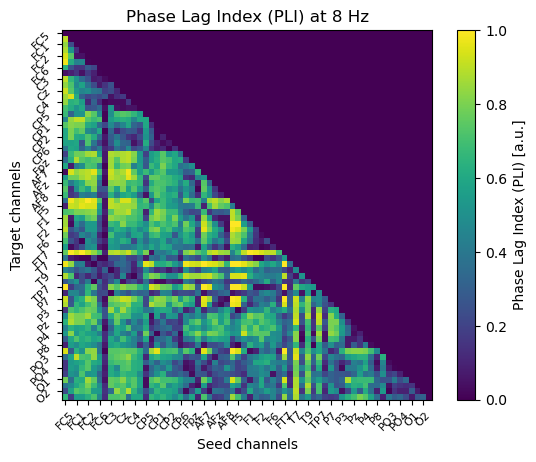

In [38]:
con_pli = mne_connectivity.spectral_connectivity_epochs(epochs, fmax=40, method="pli", verbose=False)
utils.plot_connectivity_matrix(info=epochs.info, connectivity=con_pli, freq=8)

**Exercise**: Plot the connectivity between `"T7"` (close to the simulated source in primary auditory cortex) and all other electrodes at `8` Hz for both PLV and PLI and compare the two topoplots.

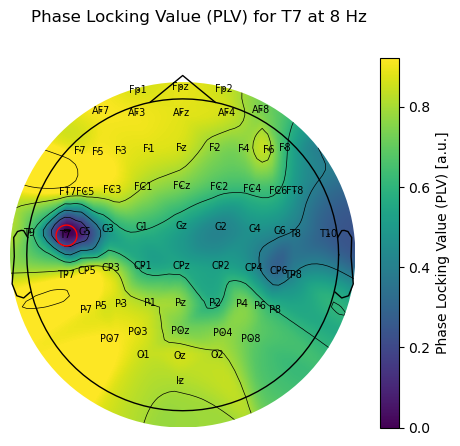

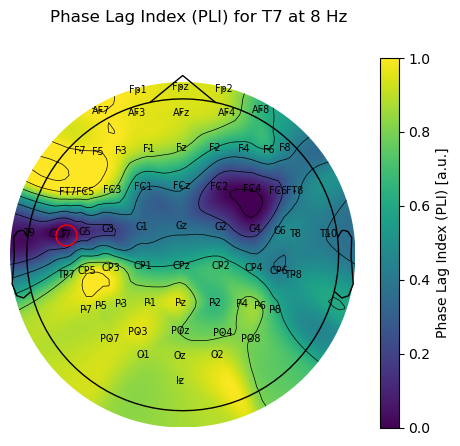

In [ ]:
freq = 8
ch = "T7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_plv, freq=freq)
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_pli, freq=freq)

**Exercise**: Plot the connectivity between `"F7"` (close to the simulated source in Broca's area) and all other electrodes at `8` Hz for both PLV and PLI and compare the two topoplots.

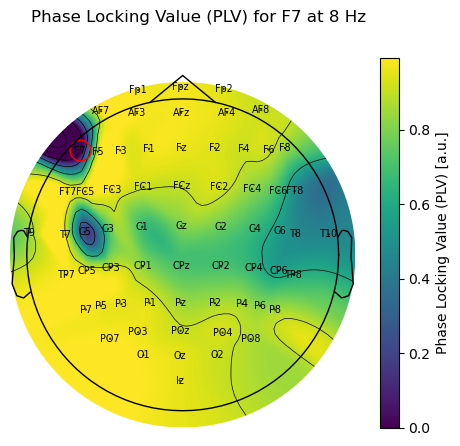

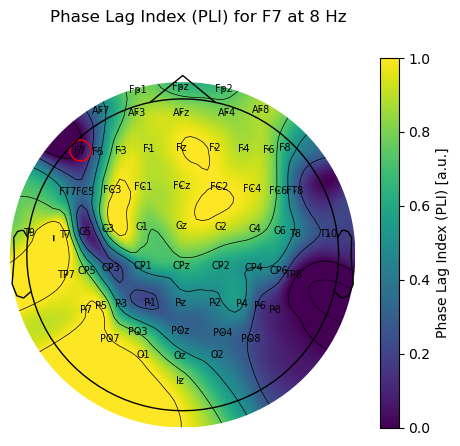

In [40]:
freq = 8
ch = "F7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_plv, freq=freq)
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_pli, freq=freq)

**Exercise**: Plot the connectivity between `"T7"` (primary auditory cortex) and `"F7"` (Broca's area) across frequencies both for PLI and PLV and compare the two plots.

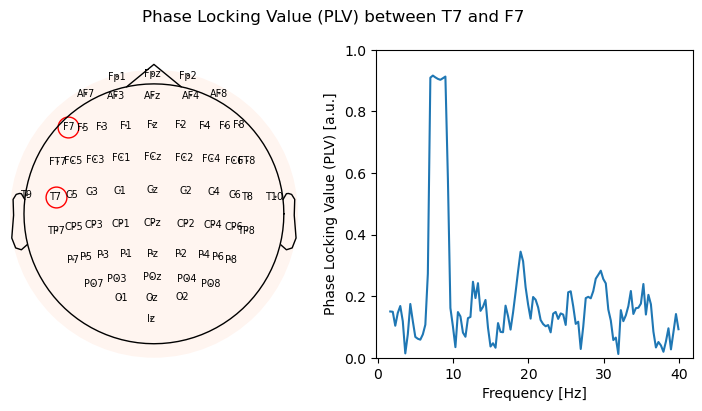

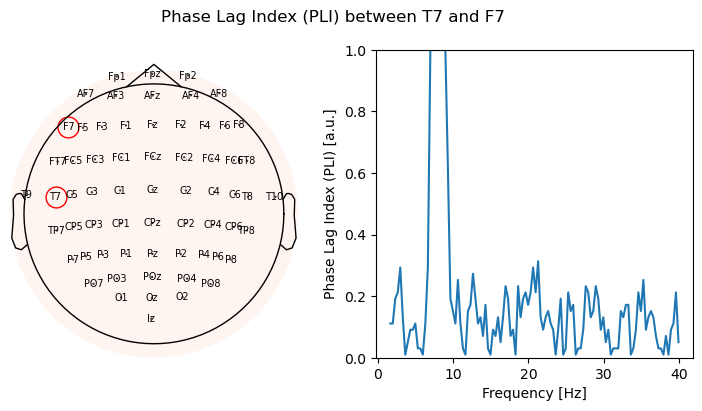

In [41]:
ch1 = "T7"
ch2 = "F7"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=con_plv)
utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=con_pli)

**Exercise**: Plot the connectivity between `"T7"` and its neighbor `"T9"` across frequencies both for PLI and PLV and compare the two plots.

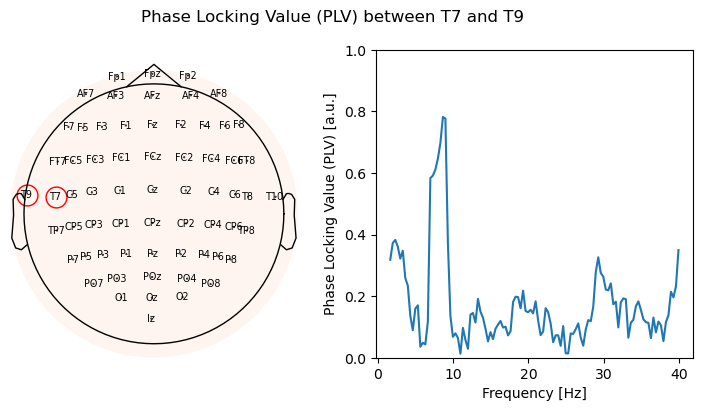

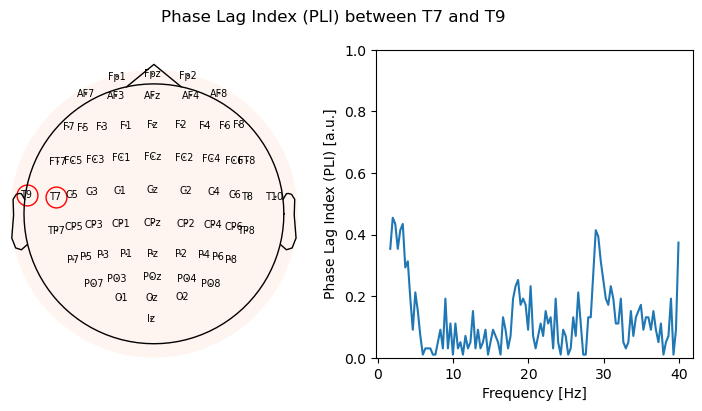

In [42]:
ch1 = "T7"
ch2 = "T9"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=con_plv)
utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=con_pli)

## Computing the Current Source Density (CSD) to Overcome Volume Conductance

### Background

In the previous section, we saw that PLI can help to suppress the zero-lag connectivity values that result from volume conductance. However, non-zero lag interactions from a genuine source will still spread via volume conduction to neighboring electrodes, creating spurious non-zero-lag connectivity between channels that don't correspond to the true sources.

To help with this, we can apply the CSD transform (also known as surface Laplacian). Instead of measuring the absolute voltage at each electrode, it measures how much the voltage at that electrode differs from its neighbors which is an estimate of the local current flowing into or out of the scalp surface. Because volume-conducted activity appears as a smooth, spatially broad pattern with small differences between neighboring electrodes, the CSD is an effective preprocessing method for removing the effect of volume conductance.

The trade-off is that the CSD requires a good spatial sampling of the scalp and amplifies noise at electrodes with few neighbors. It also distorts the absolute amplitude of the signal.

### Exercises

In this section, we will compute connectivity using PLV and PLI on a CSD-transformed version of the simulated epochs. The commands are the same as in the previous sections - here is a reminder:


| Code | Description |
| --- | --- |
| `csd = mne.preprocessing.compute_current_source_density(epochs)` | Apply the CSD transform to `epochs` |
| `mne_connectivity.spectral_connectivity_epochs(data=csd, method="plv")` | Compute connectivity on CSD-transformed data |
| `utils.plot_connectivity_topo(ch, info, connectivity, freq)` | Create a topoplot for the connectivity between `ch` and every other channel at the frequency `freq` |

Run the cell below to compute the current source density and plot the ERP for the original `epochs` as well as the `csd`. How does the scalp distribution differ between the two?

Fitted sphere radius:         95.6 mm
Origin head coordinates:      -0.8 15.1 44.6 mm
Origin device coordinates:    -0.8 15.1 44.6 mm
No projector specified for this dataset. Please consider the method self.add_proj.


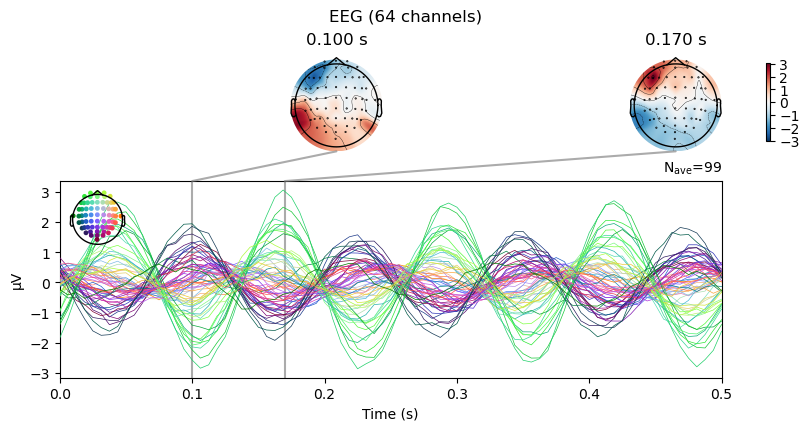

No projector specified for this dataset. Please consider the method self.add_proj.


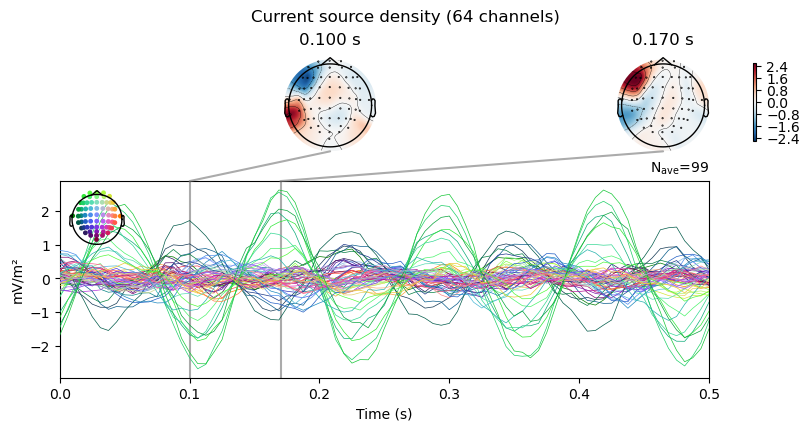

In [43]:
csd = mne.preprocessing.compute_current_source_density(epochs)
epochs.average().crop(0, 0.5).plot_joint(times=[0.1, 0.17]);
csd.average().crop(0, 0.5).plot_joint(times=[0.1, 0.17]);

**Example**: Compute the connectivity using the `"plv"` method for the CSD-transformed data and plot the connectivity between `"F7"` and all other electrodes at 8 Hz for both the original `epochs` and the `csd` and compare both topoplots.

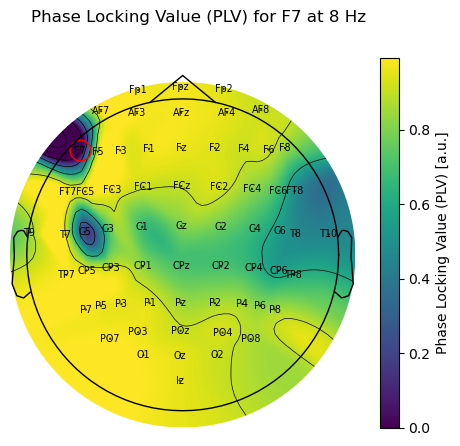

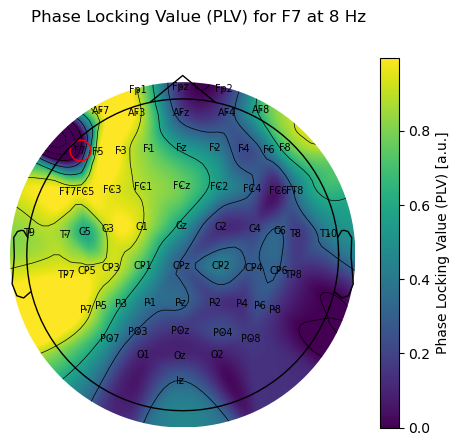

In [44]:
con_plv_csd = mne_connectivity.spectral_connectivity_epochs(data=csd, fmax=40, method="plv", verbose=False)
freq = 8
ch = "F7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_plv, freq=freq)
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_plv_csd, freq=freq)

**Exercise**: Compute the connectivity using the `"pli"` method for the CSD-transformed data and plot the connectivity between `"F7"` and all other electrodes at 8 Hz for both the original `epochs` and the `csd` and compare both topoplots.

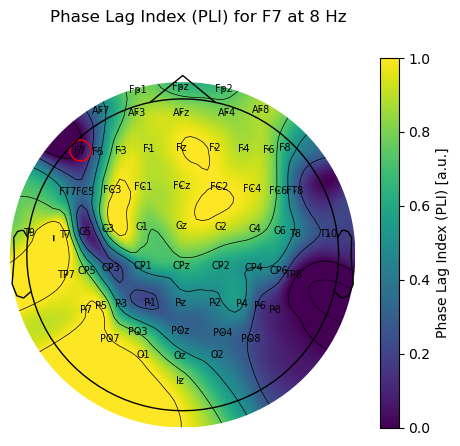

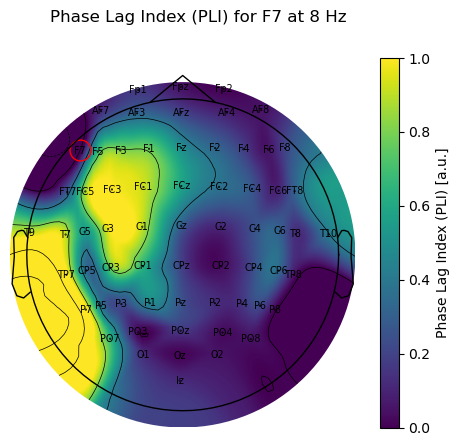

In [45]:
con_pli_csd = mne_connectivity.spectral_connectivity_epochs(data=csd, fmax=40, method="pli", verbose=False)
freq = 8
ch = "F7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_pli, freq=freq)
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=con_pli_csd, freq=freq)